In [54]:
%pip install matplotlib
%pip install seaborn

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.manifold import TSNE
import json
import os
from collections import defaultdict

In [56]:
# Setup
sns.set_palette("husl") # Set a color palette for seaborn plots

# ========== SCAN FOLDER ==========
raw_data_dir = 'd:/Master DS/Intro_to_DS/data_real'

# Speaker Dataset Statistics & Visualization

In [57]:
folders = [
    f for f in os.listdir(raw_data_dir)
    if os.path.isdir(os.path.join(raw_data_dir, f))
]

print("Số folder:", len(folders))
print(folders)

Số folder: 41
['Bao_Hue', 'Chau_Anh', 'Cong_Phuong', 'Danh_Son', 'Duc', 'Hai_Phan', 'Hai_Yen', 'Hoang_Hiep', 'Hung', 'Huong_Ly', 'Huyen_Trang', 'Jenifer_Smith', 'Khanh_Huyen', 'Le_Ha', 'Le_Nghi', 'Lien', 'Linh_Dao', 'Long_Hai', 'Ly_Minh', 'Ly_Van_Sac', 'Minh_Tam', 'Nam_Minh', 'Nghi_Le', 'Nguyen_Lan', 'Nguyen_Luc', 'Nguyen_Thuy', 'Phan_Van_Tai_Em', 'Phong_Nghi', 'Phuong_Anh', 'The_Hao', 'The_Son', 'Thomas_Williams', 'Thu_Huyen', 'Tieu_Thu', 'Tran_Quyen', 'Tran_Van_Phuong', 'Trung', 'Tuan_Anh', 'Van_Anh', 'Van_Son', 'Xuan_Son']


==> Tổng cộng có 41 nhãn tương ứng 41 folders

In [58]:
# =========================
# 1. Lấy danh sách speaker folders
# =========================
def get_speaker_folders(raw_data_dir):
    return [
        f for f in os.listdir(raw_data_dir)
        if os.path.isdir(os.path.join(raw_data_dir, f))
    ]
get_speaker_folders(raw_data_dir)

['Bao_Hue',
 'Chau_Anh',
 'Cong_Phuong',
 'Danh_Son',
 'Duc',
 'Hai_Phan',
 'Hai_Yen',
 'Hoang_Hiep',
 'Hung',
 'Huong_Ly',
 'Huyen_Trang',
 'Jenifer_Smith',
 'Khanh_Huyen',
 'Le_Ha',
 'Le_Nghi',
 'Lien',
 'Linh_Dao',
 'Long_Hai',
 'Ly_Minh',
 'Ly_Van_Sac',
 'Minh_Tam',
 'Nam_Minh',
 'Nghi_Le',
 'Nguyen_Lan',
 'Nguyen_Luc',
 'Nguyen_Thuy',
 'Phan_Van_Tai_Em',
 'Phong_Nghi',
 'Phuong_Anh',
 'The_Hao',
 'The_Son',
 'Thomas_Williams',
 'Thu_Huyen',
 'Tieu_Thu',
 'Tran_Quyen',
 'Tran_Van_Phuong',
 'Trung',
 'Tuan_Anh',
 'Van_Anh',
 'Van_Son',
 'Xuan_Son']

In [93]:
# Scan all files to report extensions and identify audio extensions present
ext_counts = defaultdict(int)
ext_examples = defaultdict(list)
total_files = 0

for root, _, fnames in os.walk(raw_data_dir):
    for fname in fnames:
        total_files += 1
        ext = os.path.splitext(fname)[1].lower() or '<no_ext>'
        ext_counts[ext] += 1
        if len(ext_examples[ext]) < 5:
            ext_examples[ext].append(os.path.join(root, fname))

audio_exts = {'.wav', '.mp3', '.flac', '.m4a', '.aac', '.ogg', '.wma', '.aiff', '.aif', '.opus'}

print(f"Total files scanned: {total_files}\n")

print("All extensions found (sorted by count):")
for ext, cnt in sorted(ext_counts.items(), key=lambda x: -x[1]):
    print(f"{ext}: {cnt}")

print("\nAudio extensions present:")
for ext in sorted(ext_counts):
    if ext in audio_exts:
        print(f"{ext}: {ext_counts[ext]}")

print("\nExample files for each audio extension (up to 5):")
for ext in sorted(ext_counts):
    if ext in audio_exts:
        for p in ext_examples[ext]:
            print(f"{ext}: {p}")

Total files scanned: 1669

All extensions found (sorted by count):
.wav: 840
.mp3: 829

Audio extensions present:
.mp3: 829
.wav: 840

Example files for each audio extension (up to 5):
.mp3: D:\Master DS\Intro_to_DS\data_real\Bao_Hue\Bao_Hue.mp3
.mp3: D:\Master DS\Intro_to_DS\data_real\Bao_Hue\Bao_Hue_aug_10_pitch.mp3
.mp3: D:\Master DS\Intro_to_DS\data_real\Bao_Hue\Bao_Hue_aug_11_pitch.mp3
.mp3: D:\Master DS\Intro_to_DS\data_real\Bao_Hue\Bao_Hue_aug_12_pitch.mp3
.mp3: D:\Master DS\Intro_to_DS\data_real\Bao_Hue\Bao_Hue_aug_13_shift.mp3
.wav: D:\Master DS\Intro_to_DS\data_real\Chau_Anh\aug_10_noise.wav
.wav: D:\Master DS\Intro_to_DS\data_real\Chau_Anh\aug_11_stretch_0.90.wav
.wav: D:\Master DS\Intro_to_DS\data_real\Chau_Anh\aug_12_pitch_-0.7.wav
.wav: D:\Master DS\Intro_to_DS\data_real\Chau_Anh\aug_13_shift.wav
.wav: D:\Master DS\Intro_to_DS\data_real\Chau_Anh\aug_14_volume.wav


In [94]:
# Đếm số sample cho từng speaker bằng cách duyệt đệ quy các folder con
# Đếm các file có đuôi .wav hoặc .mp3 (có thể điều chỉnh nếu có các định dạng khác)

sample_counts = []

for speaker in sorted(get_speaker_folders(raw_data_dir)):
    speaker_path = os.path.join(raw_data_dir, speaker)
    count = 0

    for root, _, files in os.walk(speaker_path):
        count += sum(1 for file in files if file.lower().endswith((".wav", ".mp3")))
    sample_counts.append({"speaker": speaker, "n_samples": count})

sample_counts_df = pd.DataFrame(sample_counts).sort_values("speaker").reset_index(drop=True)
print(sample_counts_df)

print("\nTổng số sample:", sample_counts_df["n_samples"].sum())

            speaker  n_samples
0           Bao_Hue         41
1          Chau_Anh         41
2       Cong_Phuong         41
3          Danh_Son         41
4               Duc         41
5          Hai_Phan         40
6           Hai_Yen         41
7        Hoang_Hiep         40
8              Hung         41
9          Huong_Ly         41
10      Huyen_Trang         41
11    Jenifer_Smith         41
12      Khanh_Huyen         40
13            Le_Ha         40
14          Le_Nghi         40
15             Lien         41
16         Linh_Dao         41
17         Long_Hai         41
18          Ly_Minh         41
19       Ly_Van_Sac         41
20         Minh_Tam         41
21         Nam_Minh         41
22          Nghi_Le         40
23       Nguyen_Lan         41
24       Nguyen_Luc         41
25      Nguyen_Thuy         40
26  Phan_Van_Tai_Em         41
27       Phong_Nghi         40
28       Phuong_Anh         41
29          The_Hao         41
30          The_Son         41
31  Thom

In [61]:
# =========================
# 2. Tính thống kê cho từng speaker
# =========================
def compute_speaker_stats(raw_data_dir):
    stats = []

    speaker_folders = get_speaker_folders(raw_data_dir)

    for speaker in sorted(speaker_folders):
        speaker_path = os.path.join(raw_data_dir, speaker)

        file_count = 0
        durations = []
        sizes_mb = []

        # Duyệt đệ quy toàn bộ file bên trong folder speaker
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if not file.lower().endswith((".wav", ".mp3")):
                    continue

                file_path = os.path.join(root, file)

                try:
                    file_count += 1

                    size_mb = os.path.getsize(file_path) / (1024 * 1024)
                    sizes_mb.append(size_mb)

                    y, sr = librosa.load(file_path, sr=None)
                    duration = librosa.get_duration(y=y, sr=sr)
                    durations.append(duration)

                except Exception as e:
                    print(f"Skip {file_path}: {e}")

        stats.append({
            "speaker": speaker,
            "n_files": file_count,
            "total_duration_sec": np.sum(durations),
            "avg_duration_sec": np.mean(durations) if durations else 0,
            "total_size_mb": np.sum(sizes_mb),
            "avg_size_mb": np.mean(sizes_mb) if sizes_mb else 0,
        })

    return pd.DataFrame(stats)


In [62]:
# =========================
# 3. Hiển thị bảng thống kê
# =========================
def show_summary(df):
    print(df)
    print("\nTổng số speaker:", len(df))
    print("Tổng số file:", df["n_files"].sum())



In [63]:
show_summary(compute_speaker_stats(raw_data_dir))

            speaker  n_files  total_duration_sec  avg_duration_sec  \
0           Bao_Hue       41          160.832313          3.922739   
1          Chau_Anh       41          172.916054          4.217465   
2       Cong_Phuong       41          194.258481          4.738012   
3          Danh_Son       41          164.448390          4.010936   
4               Duc       41          176.255526          4.298915   
5          Hai_Phan       40          180.987833          4.524696   
6           Hai_Yen       41          136.117604          3.319942   
7        Hoang_Hiep       40          166.347417          4.158685   
8              Hung       41          165.897625          4.046284   
9          Huong_Ly       41          177.238141          4.322881   
10      Huyen_Trang       41          180.088949          4.392413   
11    Jenifer_Smith       41          233.749625          5.701210   
12      Khanh_Huyen       40          183.334500          4.583362   
13            Le_Ha 

In [64]:

# =========================
# 4. Vẽ số lượng file theo speaker
# =========================
def plot_file_counts(df):
    plt.figure(figsize=(12, 5))
    plt.bar(df["speaker"], df["n_files"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("# Files")
    plt.title("Number of audio files per speaker")
    plt.tight_layout()
    plt.show()

In [65]:
# =========================
# 5. Vẽ tổng duration theo speaker
# =========================
def plot_total_duration(df):
    plt.figure(figsize=(12, 5))
    plt.bar(df["speaker"], df["total_duration_sec"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Duration (sec)")
    plt.title("Total audio duration per speaker")
    plt.tight_layout()
    plt.show()

In [66]:
# =========================
# 6. Vẽ average duration theo speaker
# =========================
def plot_avg_duration(df):
    plt.figure(figsize=(12, 5))
    plt.bar(df["speaker"], df["avg_duration_sec"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Average duration (sec)")
    plt.title("Average audio duration per speaker")
    plt.tight_layout()
    plt.show()

In [67]:
# =========================
# 7. Vẽ biểu đồ tròn phân bố dữ liệu theo speaker
# =========================
def plot_speakers_pie_chart(df):
    plt.figure(figsize=(14, 8))
    
    # Sử dụng colormap với đủ màu sắc
    num_speakers = len(df)
    if num_speakers <= 10:
        colors = plt.cm.tab10(range(num_speakers))
    elif num_speakers <= 20:
        colors = plt.cm.tab20(range(num_speakers))
    else:
        colors = plt.cm.hsv(np.linspace(0, 1, num_speakers))
    
    wedges, texts, autotexts = plt.pie(
        df["n_files"], 
        labels=df["speaker"],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10}
    )
    
    # Làm cho phần trăm dễ đọc hơn
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    plt.title("Phân bố dữ liệu theo speaker", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [68]:
# =========================
# 8. Duration Distribution Histogram
# =========================
def plot_duration_histogram(raw_data_dir):
    all_durations = []
    
    for speaker in get_speaker_folders(raw_data_dir):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if not file.lower().endswith((".wav", ".mp3")):
                    continue
                
                file_path = os.path.join(root, file)
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    duration = librosa.get_duration(y=y, sr=sr)
                    all_durations.append(duration)
                except:
                    pass
    
    plt.figure(figsize=(12, 5))
    plt.hist(all_durations, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Audio Duration Across All Speakers")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Duration Statistics:")
    print(f"  Min: {np.min(all_durations):.2f}s")
    print(f"  Max: {np.max(all_durations):.2f}s")
    print(f"  Mean: {np.mean(all_durations):.2f}s")
    print(f"  Median: {np.median(all_durations):.2f}s")
    print(f"  Std Dev: {np.std(all_durations):.2f}s")

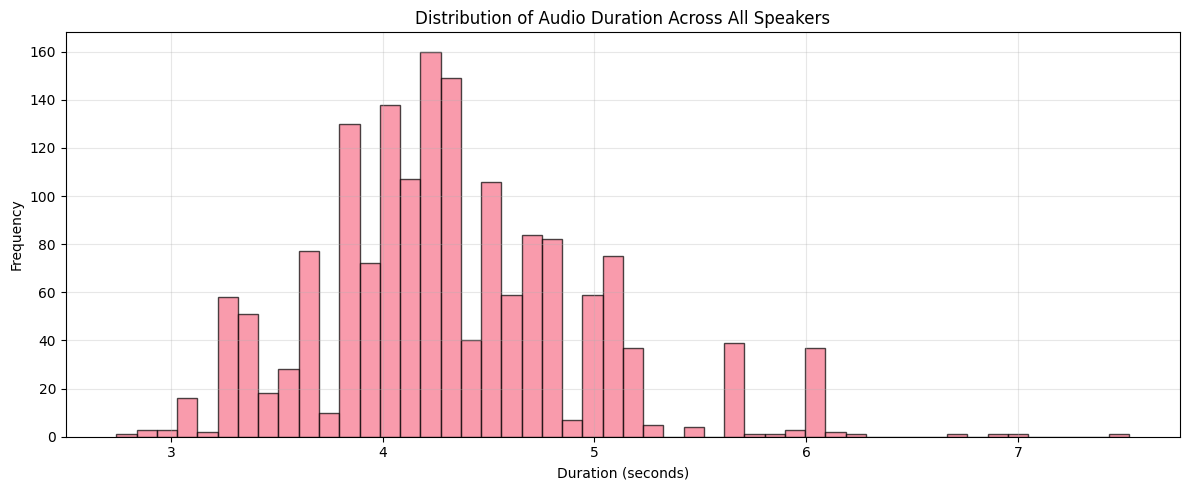

Duration Statistics:
  Min: 2.74s
  Max: 7.53s
  Mean: 4.31s
  Median: 4.23s
  Std Dev: 0.63s


In [69]:
plot_duration_histogram(raw_data_dir)

In [70]:
# =========================
# 9. Box Plot - Duration per Speaker
# =========================
def plot_duration_boxplot(raw_data_dir):
    data_for_boxplot = []
    
    for speaker in sorted(get_speaker_folders(raw_data_dir)):
        speaker_path = os.path.join(raw_data_dir, speaker)
        durations = []
        
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if not file.lower().endswith((".wav", ".mp3")):
                    continue
                
                file_path = os.path.join(root, file)
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    duration = librosa.get_duration(y=y, sr=sr)
                    durations.append(duration)
                except:
                    pass
        
        data_for_boxplot.append(durations)
    
    plt.figure(figsize=(14, 6))
    bp = plt.boxplot(data_for_boxplot, labels=sorted(get_speaker_folders(raw_data_dir)), patch_artist=True)
    
    # Màu cho các box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Duration (seconds)")
    plt.title("Audio Duration Distribution by Speaker (Box Plot)")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [71]:
# =========================
# 10. Sample Spectrograms per Speaker
# =========================
def plot_sample_spectrograms(raw_data_dir, num_speakers=5):
    """Plot 1 spectrogram sample per speaker"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    fig, axes = plt.subplots(num_speakers, 1, figsize=(12, 4*num_speakers))
    if num_speakers == 1:
        axes = [axes]
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        # Lấy file đầu tiên của speaker
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                S = librosa.feature.melspectrogram(y=y, sr=sr)
                S_db = librosa.power_to_db(S, ref=np.max)
                
                img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[idx])
                axes[idx].set_title(f'Spectrogram - Speaker: {speaker} (1 sample)')
                fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error loading {speaker}', ha='center')
    
    plt.tight_layout()
    plt.show()


# =========================
# 10b. Multiple Spectrograms per Speaker (detailed view)
# =========================
def plot_multiple_spectrograms_per_speaker(raw_data_dir, speaker_name, num_files=4):
    """Plot multiple spectrograms from one speaker to see diversity"""
    speaker_path = os.path.join(raw_data_dir, speaker_name)
    
    audio_files = []
    for root, _, files in os.walk(speaker_path):
        for file in files:
            if file.lower().endswith((".wav", ".mp3")):
                audio_files.append(os.path.join(root, file))
    
    if not audio_files:
        print(f"No audio files found for speaker: {speaker_name}")
        return
    
    # Lấy random files
    import random
    sample_files = random.sample(audio_files, min(num_files, len(audio_files)))
    
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(12, 4*len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]
    
    for idx, file_path in enumerate(sample_files):
        try:
            y, sr = librosa.load(file_path, sr=None)
            S = librosa.feature.melspectrogram(y=y, sr=sr)
            S_db = librosa.power_to_db(S, ref=np.max)
            
            duration = librosa.get_duration(y=y, sr=sr)
            
            img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[idx])
            axes[idx].set_title(f'{speaker_name} - File: {os.path.basename(file_path)} (Duration: {duration:.1f}s)')
            fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Speaker '{speaker_name}' has {len(audio_files)} total files")
    print(f"Showing {len(sample_files)} random samples")

In [72]:
# =========================
# 11. Data Balance Analysis
# =========================
def plot_data_balance(df):
    # Sort by number of files
    df_sorted = df.sort_values('n_files', ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Top 5 speakers with most data
    top_5 = df_sorted.tail(5)
    axes[0].barh(top_5['speaker'], top_5['n_files'], color='green', alpha=0.7)
    axes[0].set_xlabel('Number of Files')
    axes[0].set_title('Top 5 Speakers (Most Data)')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Bottom 5 speakers with least data
    bottom_5 = df_sorted.head(5)
    axes[1].barh(bottom_5['speaker'], bottom_5['n_files'], color='red', alpha=0.7)
    axes[1].set_xlabel('Number of Files')
    axes[1].set_title('Bottom 5 Speakers (Least Data)')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print balance statistics
    print("\n" + "="*50)
    print("DATA BALANCE ANALYSIS")
    print("="*50)
    print(f"Mean files per speaker: {df['n_files'].mean():.1f}")
    print(f"Std Dev: {df['n_files'].std():.1f}")
    print(f"Min files: {df['n_files'].min()}")
    print(f"Max files: {df['n_files'].max()}")
    imbalance = (df['n_files'].max() - df['n_files'].min()) / df['n_files'].mean() * 100
    print(f"Imbalance ratio: {imbalance:.1f}%")
    print("="*50)

In [73]:
# plot_data_balance(compute_speaker_stats(raw_data_dir))
# các nhãn không có sự chênh lệch về số lượng samples

In [74]:
# =========================
# 13. MFCC Features Visualization
# =========================
def plot_mfcc_comparison(raw_data_dir, num_speakers=5, n_mfcc=13):
    """Extract and visualize MFCC features from multiple speakers"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    fig, axes = plt.subplots(num_speakers, 1, figsize=(12, 4*num_speakers))
    if num_speakers == 1:
        axes = [axes]
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        # Lấy file đầu tiên
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                
                # Extract MFCC features
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
                
                # Plot heatmap
                img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', y_axis='mel_hz', ax=axes[idx])
                axes[idx].set_title(f'MFCC - Speaker: {speaker}')
                fig.colorbar(img, ax=axes[idx], format='%+2.0f')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    plt.tight_layout()
    plt.show()
    print(f"MFCC Features extracted ({n_mfcc} coefficients) for {num_speakers} speakers")


# =========================
# 13b. MFCC Heatmap Comparison (multiple speakers side-by-side)
# =========================
def plot_mfcc_heatmap_comparison(raw_data_dir, num_speakers=4, n_mfcc=13):
    """Compare MFCC features in a grid layout"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    cols = 2
    rows = (num_speakers + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5*rows))
    axes = axes.flatten()
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
                
                im = axes[idx].imshow(mfcc, aspect='auto', origin='lower')
                axes[idx].set_title(f'{speaker}', fontsize=12, fontweight='bold')
                axes[idx].set_xlabel('Time')
                axes[idx].set_ylabel('MFCC Coefficient')
                plt.colorbar(im, ax=axes[idx])
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    # Hide empty subplots
    for idx in range(len(speakers), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [75]:
# =========================
# 14. Waveform Comparison
# =========================
def plot_waveform_comparison(raw_data_dir, num_speakers=5):
    """Plot raw waveforms from multiple speakers"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    fig, axes = plt.subplots(num_speakers, 1, figsize=(14, 3*num_speakers))
    if num_speakers == 1:
        axes = [axes]
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        # Lấy file đầu tiên
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)
                
                # Create time axis
                time_axis = np.linspace(0, duration, len(y))
                
                # Plot waveform
                axes[idx].plot(time_axis, y, linewidth=0.5, color='steelblue', alpha=0.8)
                axes[idx].fill_between(time_axis, y, alpha=0.3, color='steelblue')
                axes[idx].set_title(f'Waveform - {speaker} (Duration: {duration:.2f}s, SR: {sr}Hz)', fontweight='bold')
                axes[idx].set_ylabel('Amplitude')
                axes[idx].set_xlabel('Time (seconds)')
                axes[idx].grid(alpha=0.3)
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    plt.tight_layout()
    plt.show()
    print(f"Waveforms displayed for {num_speakers} speakers")


# =========================
# 14b. Waveform Comparison for One Speaker (Multiple Files)
# =========================
def plot_waveforms_single_speaker(raw_data_dir, speaker_name, num_files=4):
    """Compare multiple waveforms from one speaker"""
    speaker_path = os.path.join(raw_data_dir, speaker_name)
    
    audio_files = []
    for root, _, files in os.walk(speaker_path):
        for file in files:
            if file.lower().endswith((".wav", ".mp3")):
                audio_files.append(os.path.join(root, file))
    
    if not audio_files:
        print(f"No audio files found for speaker: {speaker_name}")
        return
    
    import random
    sample_files = random.sample(audio_files, min(num_files, len(audio_files)))
    
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, 3*len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]
    
    for idx, file_path in enumerate(sample_files):
        try:
            y, sr = librosa.load(file_path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)
            time_axis = np.linspace(0, duration, len(y))
            
            axes[idx].plot(time_axis, y, linewidth=0.5, color='steelblue', alpha=0.8)
            axes[idx].fill_between(time_axis, y, alpha=0.3, color='steelblue')
            axes[idx].set_title(f'{speaker_name} - {os.path.basename(file_path)} ({duration:.2f}s)', fontweight='bold')
            axes[idx].set_ylabel('Amplitude')
            axes[idx].set_xlabel('Time (seconds)')
            axes[idx].grid(alpha=0.3)
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    plt.tight_layout()
    plt.show()
    print(f"Waveforms for speaker '{speaker_name}': showing {len(sample_files)} out of {len(audio_files)} files")

In [76]:
# =========================
# 15. Chromagram Visualization
# =========================
def plot_chromagram_comparison(raw_data_dir, num_speakers=5):
    """Extract and visualize Chromagram features from multiple speakers"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    fig, axes = plt.subplots(num_speakers, 1, figsize=(12, 4*num_speakers))
    if num_speakers == 1:
        axes = [axes]
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        # Lấy file đầu tiên
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                
                # Extract chromagram
                chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
                
                # Plot
                img = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=axes[idx])
                axes[idx].set_title(f'Chromagram - Speaker: {speaker}', fontweight='bold')
                fig.colorbar(img, ax=axes[idx], format='%+2.0f')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    plt.tight_layout()
    plt.show()
    print(f"Chromagram features displayed for {num_speakers} speakers")


# =========================
# 15b. Chromagram Heatmap Comparison
# =========================
def plot_chromagram_heatmap_comparison(raw_data_dir, num_speakers=4):
    """Compare Chromagram features in grid layout"""
    speakers = sorted(get_speaker_folders(raw_data_dir))[:num_speakers]
    
    cols = 2
    rows = (num_speakers + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5*rows))
    axes = axes.flatten()
    
    chroma_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(raw_data_dir, speaker)
        
        sample_file = None
        for root, _, files in os.walk(speaker_path):
            for file in files:
                if file.lower().endswith((".wav", ".mp3")):
                    sample_file = os.path.join(root, file)
                    break
            if sample_file:
                break
        
        if sample_file:
            try:
                y, sr = librosa.load(sample_file, sr=None)
                chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
                
                im = axes[idx].imshow(chroma, aspect='auto', origin='lower', cmap='viridis')
                axes[idx].set_title(f'{speaker}', fontsize=12, fontweight='bold')
                axes[idx].set_ylabel('Chroma')
                axes[idx].set_yticks(range(12))
                axes[idx].set_yticklabels(chroma_names)
                axes[idx].set_xlabel('Time')
                plt.colorbar(im, ax=axes[idx])
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {str(e)}', ha='center')
    
    # Hide empty subplots
    for idx in range(len(speakers), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [77]:
# =========================
# 12. Detailed Statistical Summary
# =========================
def print_detailed_stats(df):
    print("\n" + "="*80)
    print("DETAILED STATISTICAL SUMMARY")
    print("="*80)
    
    # Duration statistics
    print("\n📊 DURATION STATISTICS (in seconds):")
    print("-" * 80)
    print(f"{'Metric':<30} {'Mean':<15} {'Std Dev':<15} {'Min':<15} {'Max':<15}")
    print("-" * 80)
    
    duration_stats = df[['avg_duration_sec', 'total_duration_sec']].describe()
    print(f"{'Average Duration':<30} {df['avg_duration_sec'].mean():<15.2f} {df['avg_duration_sec'].std():<15.2f} {df['avg_duration_sec'].min():<15.2f} {df['avg_duration_sec'].max():<15.2f}")
    print(f"{'Total Duration per Speaker':<30} {df['total_duration_sec'].mean():<15.2f} {df['total_duration_sec'].std():<15.2f} {df['total_duration_sec'].min():<15.2f} {df['total_duration_sec'].max():<15.2f}")
    
    # File size statistics
    print("\n💾 FILE SIZE STATISTICS (in MB):")
    print("-" * 80)
    print(f"{'Metric':<30} {'Mean':<15} {'Std Dev':<15} {'Min':<15} {'Max':<15}")
    print("-" * 80)
    print(f"{'Average Size per File':<30} {df['avg_size_mb'].mean():<15.2f} {df['avg_size_mb'].std():<15.2f} {df['avg_size_mb'].min():<15.2f} {df['avg_size_mb'].max():<15.2f}")
    print(f"{'Total Size per Speaker':<30} {df['total_size_mb'].mean():<15.2f} {df['total_size_mb'].std():<15.2f} {df['total_size_mb'].min():<15.2f} {df['total_size_mb'].max():<15.2f}")
    
    # File count statistics
    print("\n📁 FILE COUNT STATISTICS:")
    print("-" * 80)
    print(f"Total speakers: {len(df)}")
    print(f"Total files: {df['n_files'].sum()}")
    print(f"Files per speaker - Mean: {df['n_files'].mean():.1f}, Std: {df['n_files'].std():.1f}, Min: {df['n_files'].min()}, Max: {df['n_files'].max()}")
    
    print("\n" + "="*80 + "\n")

In [78]:
print_detailed_stats(compute_speaker_stats(raw_data_dir))


DETAILED STATISTICAL SUMMARY

📊 DURATION STATISTICS (in seconds):
--------------------------------------------------------------------------------
Metric                         Mean            Std Dev         Min             Max            
--------------------------------------------------------------------------------
Average Duration               4.31            0.61            3.17            6.10           
Total Duration per Speaker     175.58          24.54           129.88          250.29         

💾 FILE SIZE STATISTICS (in MB):
--------------------------------------------------------------------------------
Metric                         Mean            Std Dev         Min             Max            
--------------------------------------------------------------------------------
Average Size per File          0.12            0.11            0.02            0.47           
Total Size per Speaker         5.02            4.27            0.86            18.74          

📁 FIL

In [79]:
# =========================
# Main
# =========================
raw_data_dir = r"D:\Master DS\Intro_to_DS\data_real"

stats_df = compute_speaker_stats(raw_data_dir)

# Basic summary
show_summary(stats_df)

            speaker  n_files  total_duration_sec  avg_duration_sec  \
0           Bao_Hue       41          160.832313          3.922739   
1          Chau_Anh       41          172.916054          4.217465   
2       Cong_Phuong       41          194.258481          4.738012   
3          Danh_Son       41          164.448390          4.010936   
4               Duc       41          176.255526          4.298915   
5          Hai_Phan       40          180.987833          4.524696   
6           Hai_Yen       41          136.117604          3.319942   
7        Hoang_Hiep       40          166.347417          4.158685   
8              Hung       41          165.897625          4.046284   
9          Huong_Ly       41          177.238141          4.322881   
10      Huyen_Trang       41          180.088949          4.392413   
11    Jenifer_Smith       41          233.749625          5.701210   
12      Khanh_Huyen       40          183.334500          4.583362   
13            Le_Ha 

In [80]:
# Basic visualizations
# plot_file_counts(stats_df) # số lượng file theo speaker
# plot_total_duration(stats_df) # tổng duration theo speaker
# plot_avg_duration(stats_df) # average duration theo speaker
# plot_speakers_pie_chart(stats_df) # biểu đồ tròn phân bố dữ liệu theo speaker
# plot_duration_histogram(raw_data_dir) # histogram phân bố duration
# plot_duration_boxplot(raw_data_dir) # boxplot duration theo speaker
# plot_sample_spectrograms(raw_data_dir, num_speakers=5) # spectrogram mẫu từ 5 speaker
# plot_multiple_spectrograms_per_speaker(raw_data_dir, speaker_name=stats_df['speaker'][0], num_files=4) # nhiều spectrogram từ 1 speaker
# plot_data_balance(stats_df) # phân tích cân bằng dữ liệu
# plot_mfcc_comparison(raw_data_dir, num_speakers=5) # so sánh MFCC giữa các speaker
# plot_mfcc_heatmap_comparison(raw_data_dir, num_speakers=4) # so sánh MFCC với heatmap
# plot_waveform_comparison(raw_data_dir, num_speakers=5) # so sánh waveform giữa các speaker  


ADVANCED EDA ANALYSIS


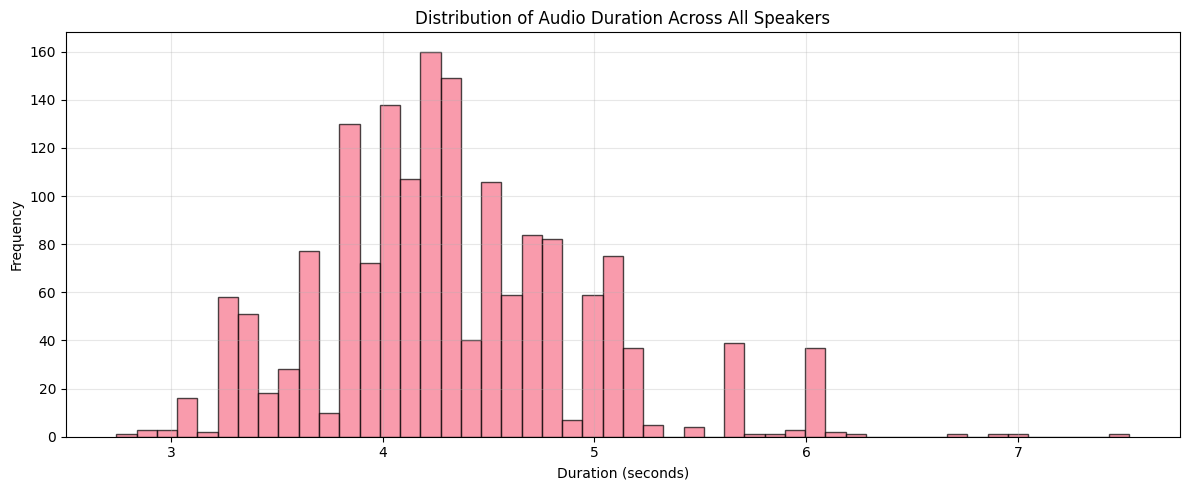

Duration Statistics:
  Min: 2.74s
  Max: 7.53s
  Mean: 4.31s
  Median: 4.23s
  Std Dev: 0.63s


In [81]:
# Advanced EDA
print("\n" + "="*50)
print("ADVANCED EDA ANALYSIS")
print("="*50)

plot_duration_histogram(raw_data_dir)  # phân bố duration

In [82]:
# plot_duration_boxplot(raw_data_dir)

In [83]:
# plot_data_balance(stats_df)

In [84]:
# Spectrograms: 1 sample per speaker
# plot_sample_spectrograms(raw_data_dir, num_speakers=5)

In [85]:
# Spectrograms: Multiple samples from ONE speaker
# plot_multiple_spectrograms_per_speaker(raw_data_dir, speaker_name='Huong_Ly', num_files=4)

In [86]:
# MFCC Features
print("\n" + "="*50)
print("AUDIO FEATURES ANALYSIS")
print("="*50)


AUDIO FEATURES ANALYSIS


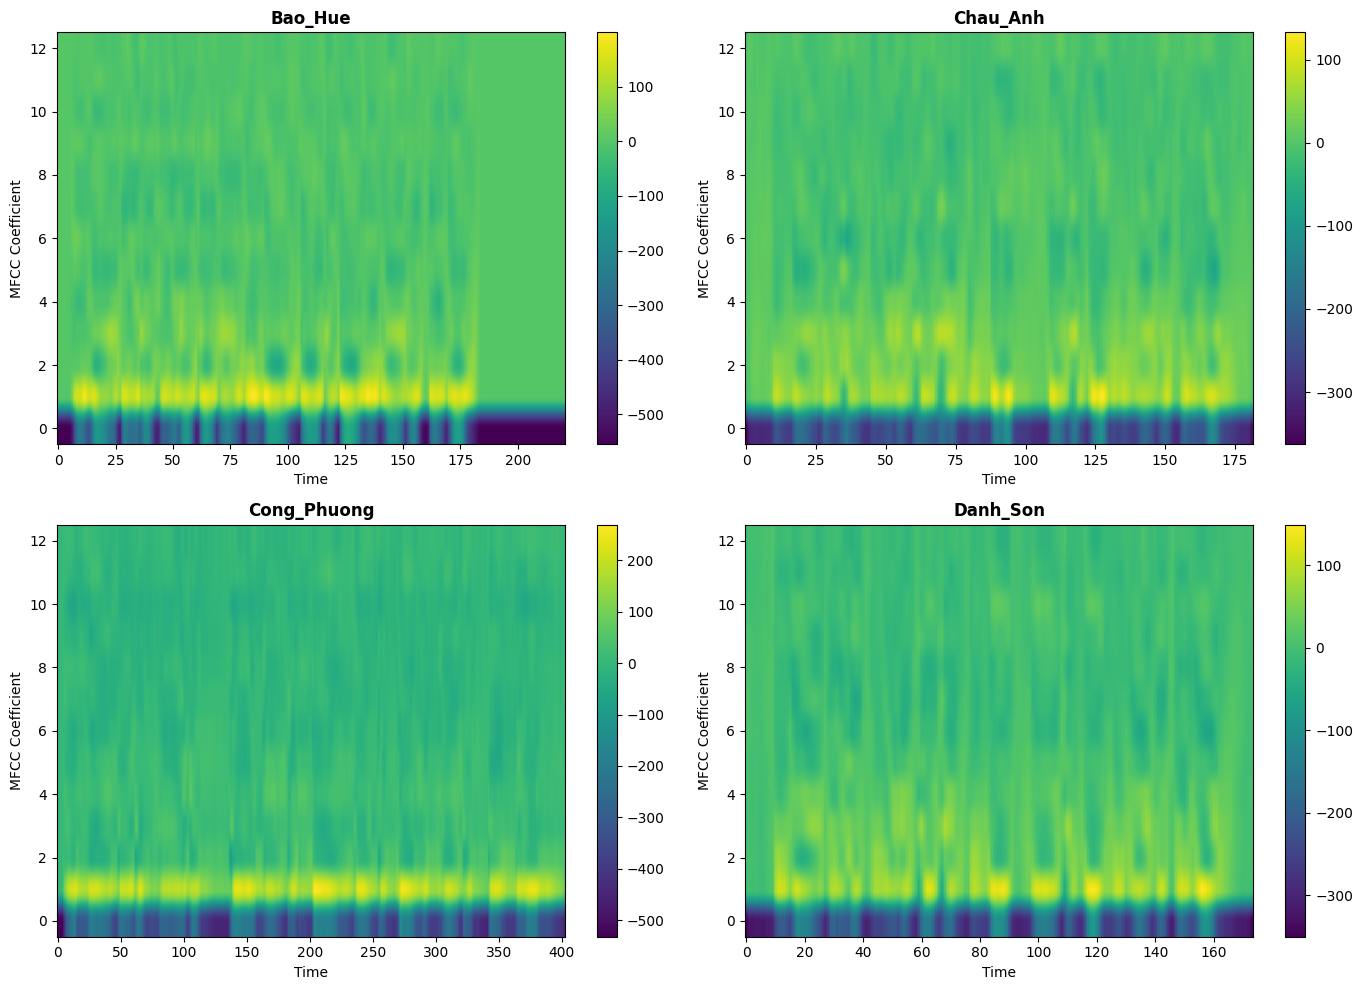

In [87]:
plot_mfcc_heatmap_comparison(raw_data_dir, num_speakers=4)

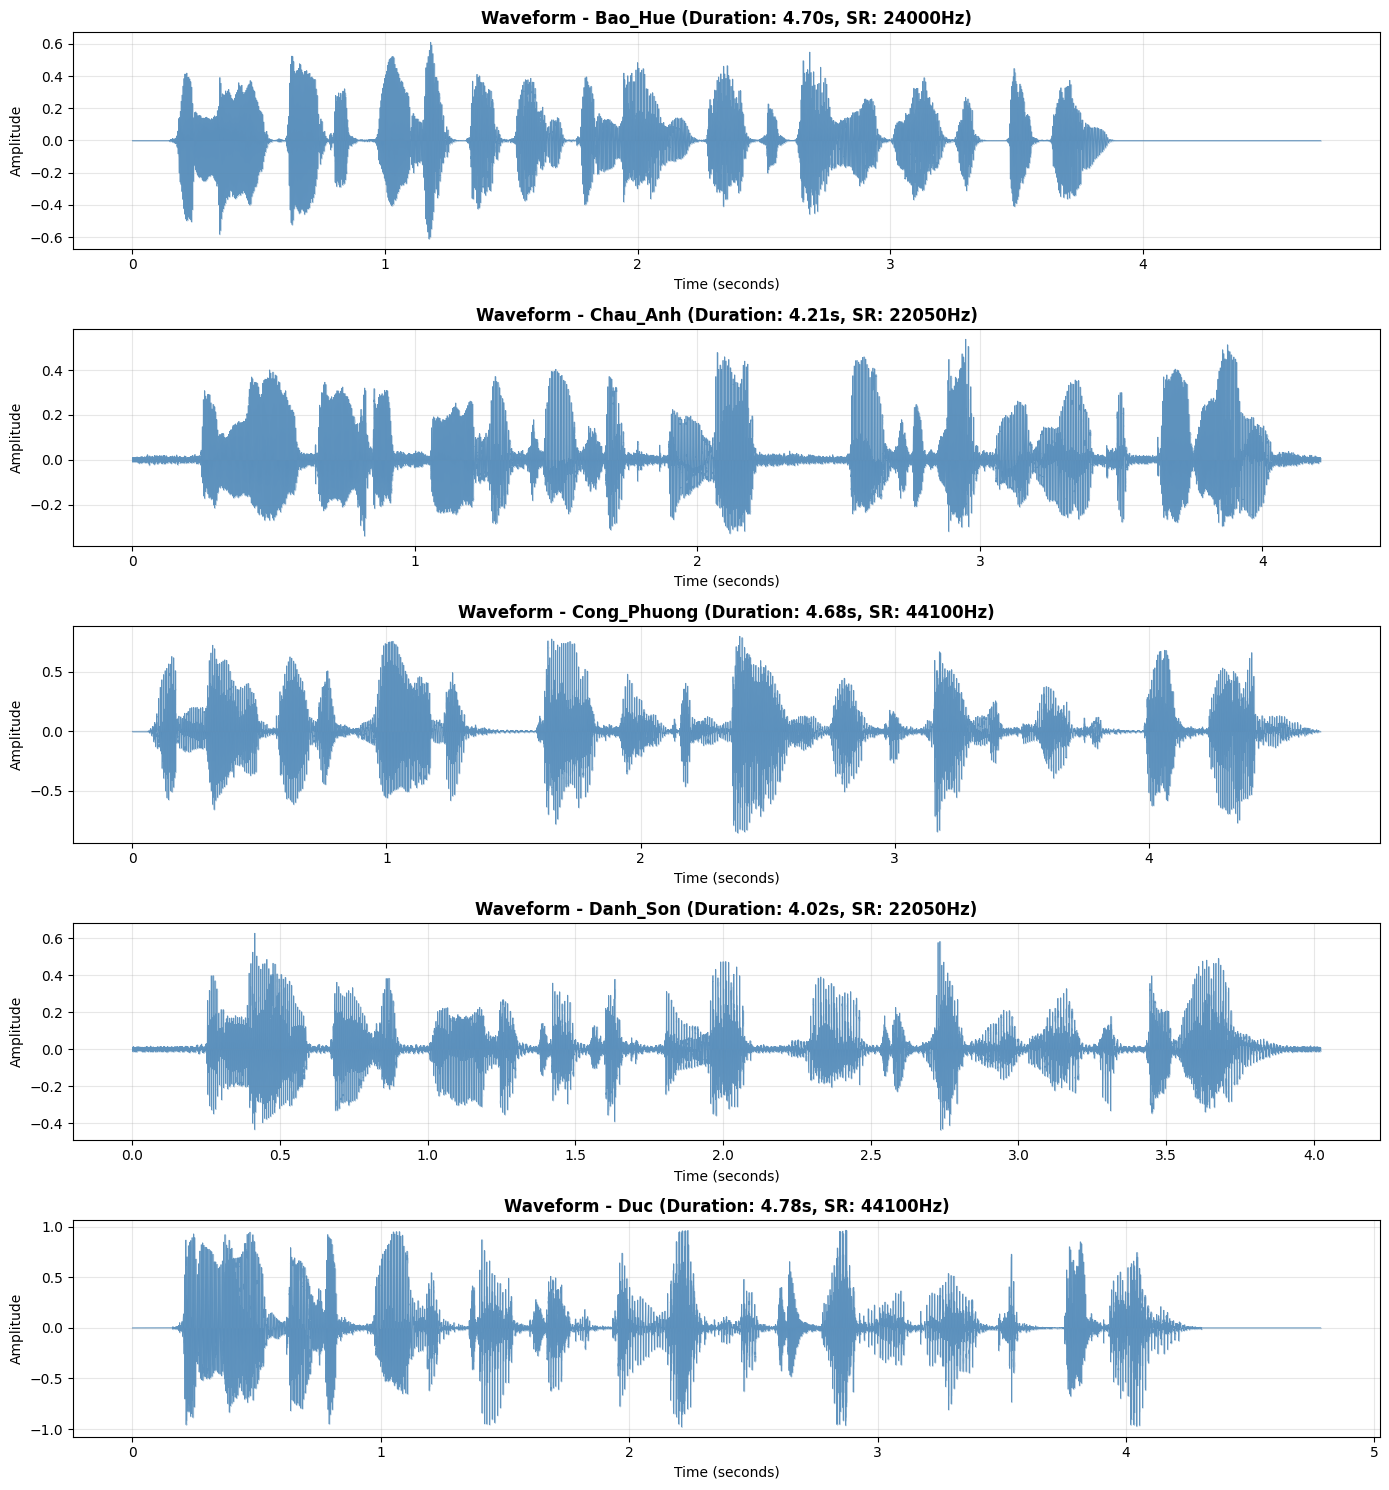

Waveforms displayed for 5 speakers


In [88]:
# Waveform Comparison
plot_waveform_comparison(raw_data_dir, num_speakers=5)

In [89]:
# plot_waveforms_single_speaker(raw_data_dir, speaker_name='Huong_Ly', num_files=3)

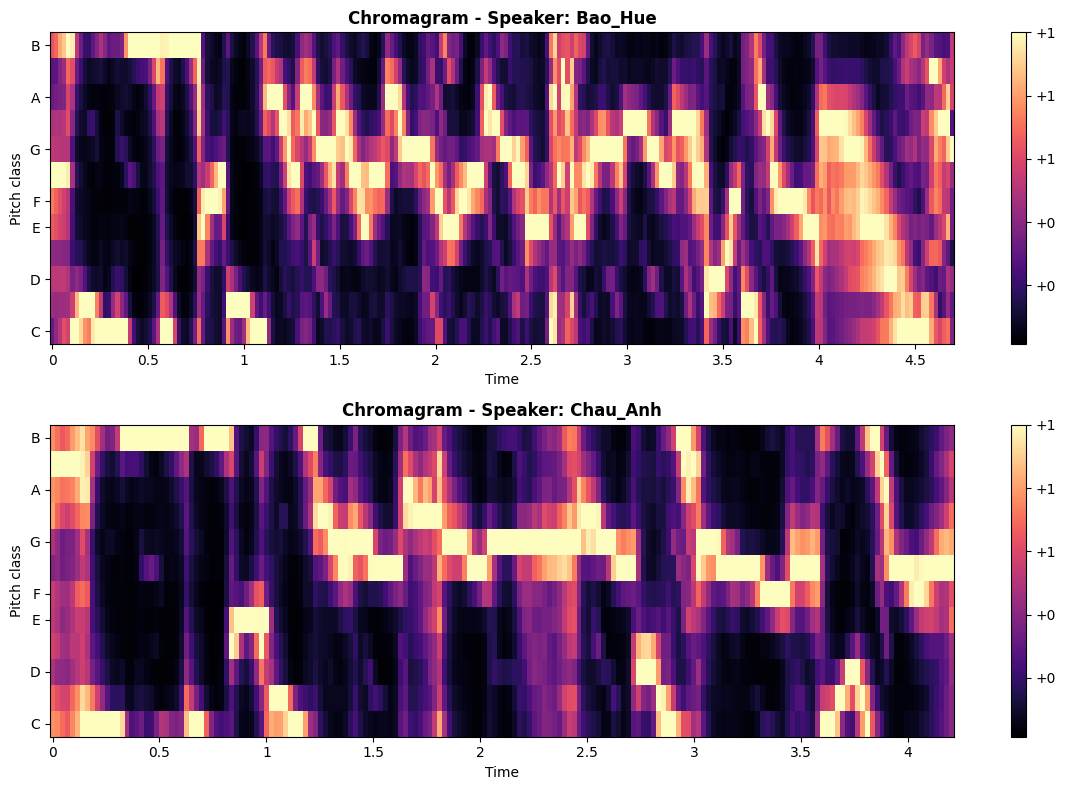

Chromagram features displayed for 2 speakers


In [90]:
# Chromagram
plot_chromagram_comparison(raw_data_dir, num_speakers=2)

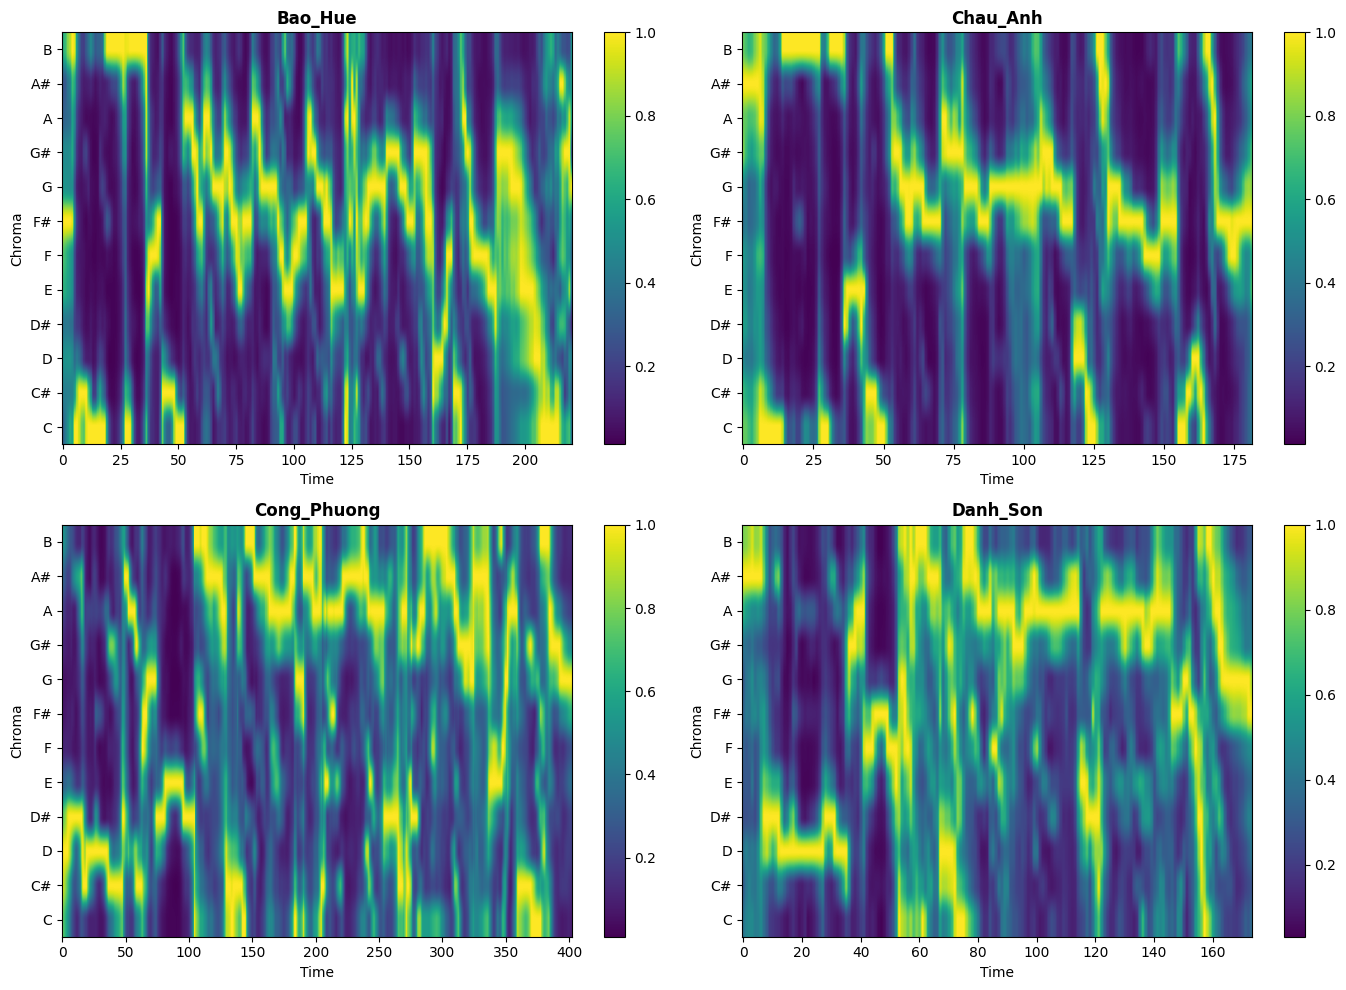

In [91]:
plot_chromagram_heatmap_comparison(raw_data_dir, num_speakers=4)

In [92]:
# Detailed statistics
print_detailed_stats(stats_df)


DETAILED STATISTICAL SUMMARY

📊 DURATION STATISTICS (in seconds):
--------------------------------------------------------------------------------
Metric                         Mean            Std Dev         Min             Max            
--------------------------------------------------------------------------------
Average Duration               4.31            0.61            3.17            6.10           
Total Duration per Speaker     175.58          24.54           129.88          250.29         

💾 FILE SIZE STATISTICS (in MB):
--------------------------------------------------------------------------------
Metric                         Mean            Std Dev         Min             Max            
--------------------------------------------------------------------------------
Average Size per File          0.12            0.11            0.02            0.47           
Total Size per Speaker         5.02            4.27            0.86            18.74          

📁 FIL